<a href="https://colab.research.google.com/github/ipeirotis/dealing_with_data/blob/master/01-Pandas/A1_Introduction_to_Pandas_Loading_and_Exploring%20Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A1: Introduction to Pandas — Loading and Exploring Data

## What is Pandas?

**Pandas** is Python's most popular library for data analysis. If you know SQL, you can think of Pandas as "SQL for Python"—but with superpowers for analysis, visualization, and machine learning integration.

The name "Pandas" comes from "Panel Data," a term from econometrics for multi-dimensional structured datasets.

## Why Use Pandas Instead of Just SQL?

Great question! You already know SQL, so why learn another tool?

| Task | SQL | Pandas |
|------|-----|--------|
| Store and query large datasets | ✅ Excellent | ⚠️ Limited by RAM |
| Filter, join, aggregate data | ✅ Yes | ✅ Yes |
| Statistical analysis | ⚠️ Limited | ✅ Excellent |
| Data visualization | ❌ No | ✅ Built-in |
| Machine learning integration | ❌ No | ✅ Seamless |
| Handle messy/unstructured data | ⚠️ Difficult | ✅ Flexible |
| Reproducible analysis scripts | ⚠️ Possible | ✅ Natural |

**The typical workflow**: Use SQL to query and filter data in the database, then bring a manageable subset into Pandas for analysis, visualization, and modeling.

## What You Will Learn

In this notebook, you will learn to:

1. **Load data** from a database into Pandas using SQL
2. **Understand the core data structures**: DataFrame and Series
3. **Explore data** using `.head()`, `.tail()`, `.shape`, `.dtypes`
4. **Generate descriptive statistics** for numeric and categorical variables
5. **Create basic visualizations**: histograms, bar charts, KDE plots

## The Dataset: NYC Restaurant Inspections

We'll work with real data from the NYC Department of Health: restaurant inspection results. Every restaurant in NYC is inspected and assigned a grade (A, B, C) based on violations found.

This dataset is:
- **Relatable**: Everyone eats at restaurants!
- **Rich**: Multiple tables, various data types, interesting patterns
- **Real**: Actual public data from NYC Open Data

You can explore the original dataset at: [NYC Open Data - Restaurant Inspections](https://data.cityofnewyork.us/Health/DOHMH-New-York-City-Restaurant-Inspection-Results/43nn-pn8j)

---

## Part 1: Setup and Database Connection

First, we need to:
1. Authenticate with Google Cloud (to access BigQuery)
2. Import the libraries we'll use
3. Configure our plotting settings

In [1]:
# ============================================================
# AUTHENTICATION - Run this cell and follow the login prompt
# ============================================================
from google.colab import auth
auth.authenticate_user()
print("✓ Authentication successful!")

✓ Authentication successful!


In [2]:
# ============================================================
# BIGQUERY SETUP
# ============================================================
!pip install -q google-cloud-bigquery
from google.cloud import bigquery

# ⚠️ IMPORTANT: Change this to your own Google Cloud project ID
# If you don't have one, ask your instructor for access
PROJECT_ID = "nyu-datasets"  # ← CHANGE THIS if needed

client = bigquery.Client(project=PROJECT_ID)
print(f"✓ Connected to BigQuery project: {PROJECT_ID}")

✓ Connected to BigQuery project: nyu-datasets


In [3]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================
import pandas as pd      # Data manipulation and analysis
import numpy as np       # Numerical computing
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns    # Statistical visualization

print(f"✓ Pandas version: {pd.__version__}")

✓ Pandas version: 2.2.2


In [4]:
# ============================================================
# CONFIGURE PLOTTING (optional but makes plots look better)
# ============================================================
%config InlineBackend.figure_format = 'retina'  # High-resolution plots
plt.rcParams['figure.figsize'] = [10, 4]        # Default figure size
plt.rcParams['font.size'] = 11                  # Readable font size
sns.set_style("whitegrid")                      # Clean grid background

print("✓ Plotting configured!")

✓ Plotting configured!


---

## Part 2: Loading Data from a Database

### The Bridge from SQL to Pandas

This is where your SQL knowledge pays off! We write a SQL query, execute it, and load the results directly into a Pandas DataFrame.

```python
# The pattern:
sql = "SELECT ... FROM ... WHERE ..."
df = client.query(sql).to_dataframe()
```

The `.to_dataframe()` method converts the BigQuery result into a Pandas DataFrame.

### Our Database Schema

The restaurant inspection data is stored in three tables:

| Table | Description | Key Columns |
|-------|-------------|-------------|
| `restaurants` | Restaurant info | CAMIS (ID), DBA (name), BORO, CUISINE_DESCRIPTION |
| `inspections` | Inspection results | INSPECTION_DATE, SCORE, GRADE |
| `violations` | Specific violations | VIOLATION_CODE, VIOLATION_DESCRIPTION |

**CAMIS** is the unique restaurant identifier (like a primary key).

In [5]:
# Load restaurant information
sql = """
SELECT
    CAMIS,                    -- Unique restaurant ID
    DBA,                      -- "Doing Business As" (restaurant name)
    BUILDING,                 -- Street number
    STREET,                   -- Street name
    ZIPCODE,
    BORO,                     -- Borough (Manhattan, Brooklyn, etc.)
    CUISINE_DESCRIPTION,      -- Type of cuisine
    LATITUDE,
    LONGITUDE
FROM `nyu-datasets.doh_restaurants.restaurants`
"""

restaurants = client.query(sql).to_dataframe()
print(f"✓ Loaded {len(restaurants):,} restaurants")

✓ Loaded 21,111 restaurants


In [6]:
# Load inspection results (joining restaurants and inspections tables)
sql = """
SELECT
    R.CAMIS,
    R.DBA,
    R.ZIPCODE,
    R.BORO,
    R.CUISINE_DESCRIPTION,
    I.INSPECTION_DATE,
    I.INSPECTION_TYPE,
    I.SCORE,
    I.GRADE
FROM `nyu-datasets.doh_restaurants.restaurants` R
JOIN `nyu-datasets.doh_restaurants.inspections` I ON I.CAMIS = R.CAMIS
"""

inspections = client.query(sql).to_dataframe()
print(f"✓ Loaded {len(inspections):,} inspection records")

✓ Loaded 60,600 inspection records


---

## Part 3: Understanding DataFrames and Series

### The Two Core Data Structures

Pandas has two main data structures:

| Structure | What It Is | SQL Equivalent |
|-----------|------------|----------------|
| **DataFrame** | A 2D table with rows and columns | A table or query result |
| **Series** | A single column of data | One column from a table |

Think of it this way:
- A **DataFrame** is like an Excel spreadsheet or a SQL table
- A **Series** is like a single column from that spreadsheet

### Viewing a DataFrame

In [7]:
# Display the restaurants DataFrame
# By default, Jupyter shows the first and last few rows
display(restaurants)

,CAMIS,DBA,BUILDING,STREET,ZIPCODE,BORO,CUISINE_DESCRIPTION,LATITUDE,LONGITUDE
0,41698490,AMBASSADOR FOOD SERVICES,8 07,38 AVENUE,11101,Queens,American,40.759246,-73.943992
1,50107973,BAR VELOCE,CA2L-000,LAGUARDIA TERMINAL B,11371,Queens,Italian,40.774508,-73.872834
2,50017261,CAFE DE NOVO,94 1/2,GREENWICH STREET,10006,Manhattan,American,40.708078,-74.013551
3,50135497,EAT PRETTY,501 1/2,EAST 83 STREET,10028,Manhattan,Bakery Products/Desserts,40.773828,-73.948193
4,50092845,LA NEWYORKINA LLC,NKA,HIGH LINE PARK WEST 15TH STREET,10011,Manhattan,Frozen Desserts,NaN,NaN
...,...,...,...,...,...,...,...,...,...
21106,50129451,YALA HALAL,3271,RICHMOND AVENUE,10312,Staten Island,Pizza,40.559438,-74.169534
21107,50125433,MCDONALD'S,3267,RICHMOND AVENUE,10312,Staten Island,American,40.559512,-74.169553
21108,40395554,COUNTRY DONUTS,3235,RICHMOND AVENUE,10312,Staten Island,Donuts,40.560368,-74.169760
21109,50088694,STATEN ISLAND JUICEBAR,3231,RICHMOND AVENUE,10312,Staten Island,"Juice, Smoothies, Fruit Salads",40.560393,-74.169764


**Notice three things:**

1. **The Index** (leftmost column, in bold): Row labels (0, 1, 2, ...). Like an automatic row ID.
2. **Column Headers**: The names of each column (CAMIS, DBA, BUILDING, ...)
3. **The Data**: The actual values in each cell

### Viewing Parts of a DataFrame

In [8]:
# .head(n) shows the first n rows (default: 5)
restaurants.head(3)

,CAMIS,DBA,BUILDING,STREET,ZIPCODE,BORO,CUISINE_DESCRIPTION,LATITUDE,LONGITUDE
0,41698490,AMBASSADOR FOOD SERVICES,8 07,38 AVENUE,11101,Queens,American,40.759246,-73.943992
1,50107973,BAR VELOCE,CA2L-000,LAGUARDIA TERMINAL B,11371,Queens,Italian,40.774508,-73.872834
2,50017261,CAFE DE NOVO,94 1/2,GREENWICH STREET,10006,Manhattan,American,40.708078,-74.013551


In [9]:
# .tail(n) shows the last n rows
restaurants.tail(3)

,CAMIS,DBA,BUILDING,STREET,ZIPCODE,BORO,CUISINE_DESCRIPTION,LATITUDE,LONGITUDE
21108,40395554,COUNTRY DONUTS,3235,RICHMOND AVENUE,10312,Staten Island,Donuts,40.560368,-74.169760
21109,50088694,STATEN ISLAND JUICEBAR,3231,RICHMOND AVENUE,10312,Staten Island,"Juice, Smoothies, Fruit Salads",40.560393,-74.169764
21110,50133329,RALPH'S FAMOUS ITALIAN ICES,3241,RICHMOND AVENUE,10312,Staten Island,Frozen Desserts,40.560001,-74.169665


In [10]:
# .sample(n) shows n random rows — great for getting a feel for the data
restaurants.sample(5)

,CAMIS,DBA,BUILDING,STREET,ZIPCODE,BORO,CUISINE_DESCRIPTION,LATITUDE,LONGITUDE
14903,50066230,T & J JAMAICAN FLAVA,1257,PARK AVENUE,10029,Manhattan,Caribbean,40.787373,-73.951935
10595,50033097,CAFETERIA/MAIN KITCHEN,45,WEST 44 STREET,10036,Manhattan,American,40.755413,-73.981429
19810,41452652,CRAVE,2855,36 STREET,11103,Queens,Greek,40.766303,-73.916330
3452,41556098,UDOM THAI,661,WASHINGTON AVENUE,11238,Brooklyn,Thai,40.677375,-73.963674
5944,50014239,HUNGRY BIRD,980,MORRIS AVENUE,10456,Bronx,Indian,40.828428,-73.916869


### Extracting a Single Column (Series)

In [11]:
# Use bracket notation to extract a single column
# This returns a Series (not a DataFrame)
restaurants["DBA"]

,DBA
0,AMBASSADOR FOOD SERVICES
1,BAR VELOCE
2,CAFE DE NOVO
3,EAT PRETTY
4,LA NEWYORKINA LLC
...,...
21106,YALA HALAL
21107,MCDONALD'S
21108,COUNTRY DONUTS
21109,STATEN ISLAND JUICEBAR


In [12]:
# Check the type
print(f"restaurants is a:        {type(restaurants)}")
print(f"restaurants['DBA'] is a: {type(restaurants['DBA'])}")

restaurants is a:        <class 'pandas.core.frame.DataFrame'>
restaurants['DBA'] is a: <class 'pandas.core.series.Series'>


### 🎯 Exercise 1: Explore the Inspections DataFrame

1. Display the `inspections` DataFrame
2. Show the first 10 rows
3. Show 5 random rows
4. Extract the `GRADE` column as a Series

In [13]:
# Your code here


---

## Part 4: DataFrame Metadata

Before analyzing data, you should always understand its structure:
- How many rows and columns?
- What are the column names?
- What data types are in each column?

### Size and Shape

In [14]:
# .shape returns (rows, columns) as a tuple
print(f"Restaurants: {restaurants.shape[0]:,} rows × {restaurants.shape[1]} columns")
print(f"Inspections: {inspections.shape[0]:,} rows × {inspections.shape[1]} columns")

Restaurants: 21,111 rows × 9 columns
Inspections: 60,600 rows × 9 columns


In [15]:
# len() gives just the number of rows
print(f"Number of restaurants: {len(restaurants):,}")

Number of restaurants: 21,111


### Column Names

In [16]:
# .columns shows all column names
restaurants.columns

Index(['CAMIS', 'DBA', 'BUILDING', 'STREET', 'ZIPCODE', 'BORO',
       'CUISINE_DESCRIPTION', 'LATITUDE', 'LONGITUDE'],
      dtype='object')

In [17]:
# Convert to a list for easier reading
list(restaurants.columns)

['CAMIS',
 'DBA',
 'BUILDING',
 'STREET',
 'ZIPCODE',
 'BORO',
 'CUISINE_DESCRIPTION',
 'LATITUDE',
 'LONGITUDE']

### Data Types

Understanding data types is crucial because different operations work on different types:

| Pandas dtype | Description | Example Values |
|--------------|-------------|----------------|
| `int64` | Integer numbers | 1, 42, -7 |
| `float64` | Decimal numbers | 3.14, -2.5 |
| `object` | Text/strings (or mixed) | "Hello", "NYC" |
| `datetime64` | Dates and times | 2024-01-15 |
| `bool` | True/False | True, False |

In [18]:
# .dtypes shows the data type of each column
restaurants.dtypes

,0
CAMIS,object
DBA,object
BUILDING,object
STREET,object
ZIPCODE,object
BORO,object
CUISINE_DESCRIPTION,object
LATITUDE,float64
LONGITUDE,float64


In [19]:
# Check inspections data types — notice INSPECTION_DATE is datetime!
inspections.dtypes

,0
CAMIS,object
DBA,object
ZIPCODE,object
BORO,object
CUISINE_DESCRIPTION,object
INSPECTION_DATE,"datetime64[us, UTC]"
INSPECTION_TYPE,object
SCORE,Int64
GRADE,object


### Quick Summary with `.info()`

In [20]:
# .info() gives a comprehensive overview:
# - Number of rows and columns
# - Column names and types
# - Non-null counts (helps identify missing data)
# - Memory usage
restaurants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21111 entries, 0 to 21110
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CAMIS                21111 non-null  object 
 1   DBA                  21111 non-null  object 
 2   BUILDING             21111 non-null  object 
 3   STREET               21111 non-null  object 
 4   ZIPCODE              21111 non-null  object 
 5   BORO                 21111 non-null  object 
 6   CUISINE_DESCRIPTION  21111 non-null  object 
 7   LATITUDE             21098 non-null  float64
 8   LONGITUDE            21098 non-null  float64
dtypes: float64(2), object(7)
memory usage: 1.4+ MB


---

## Part 5: Descriptive Statistics

Now let's explore what's actually *in* the data. We use different techniques for different data types:

| Data Type | Key Methods |
|-----------|-------------|
| Numeric (int, float) | `.describe()`, `.mean()`, `.median()`, `.hist()` |
| Categorical (object) | `.value_counts()`, `.nunique()`, bar charts |
| DateTime | `.min()`, `.max()`, time-based histograms |

### Numeric Variables: The SCORE Column

In [21]:
# .describe() gives summary statistics for numeric columns
inspections["SCORE"].describe()

,SCORE
count,60600.0
mean,17.19
std,13.387047
min,0.0
25%,9.0
50%,12.0
75%,23.0
max,154.0


**Interpretation:**
- **count**: Number of non-null values
- **mean**: Average score (~13)
- **std**: Standard deviation (spread of data)
- **min/max**: Range of values
- **25%, 50%, 75%**: Quartiles (50% is the median)

**Note about SCORE**: Lower is better! A score of 0-13 = Grade A, 14-27 = Grade B, 28+ = Grade C.

In [22]:
# Individual statistics
print(f"Mean score:   {inspections['SCORE'].mean():.2f}")
print(f"Median score: {inspections['SCORE'].median():.2f}")
print(f"Std dev:      {inspections['SCORE'].std():.2f}")
print(f"Min score:    {inspections['SCORE'].min()}")
print(f"Max score:    {inspections['SCORE'].max()}")

Mean score:   17.19
Median score: 12.00
Std dev:      13.39
Min score:    0
Max score:    154


### Visualizing Numeric Data: Histograms

<Axes: >

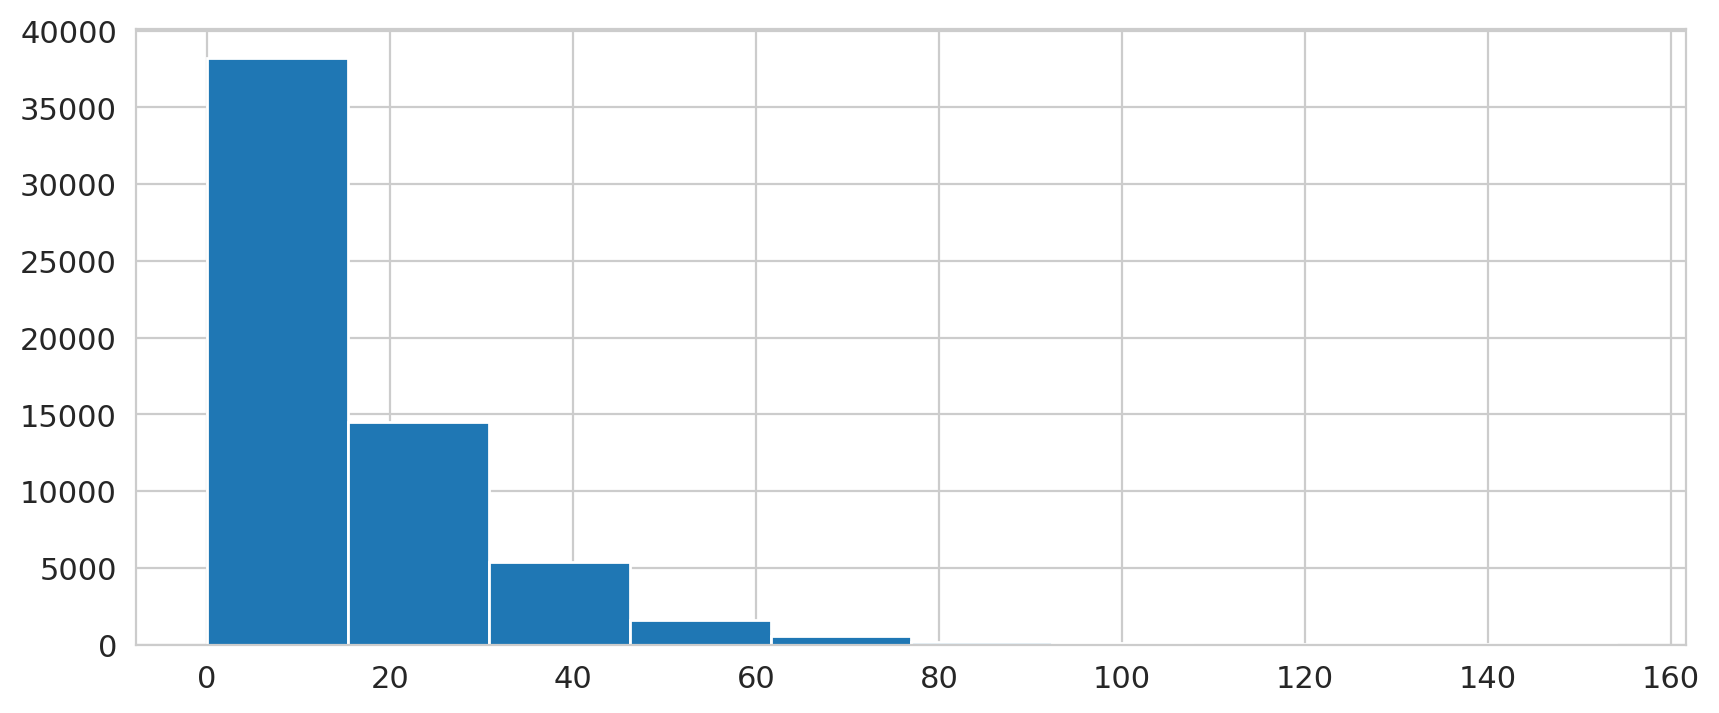

In [23]:
# Basic histogram
inspections["SCORE"].hist()

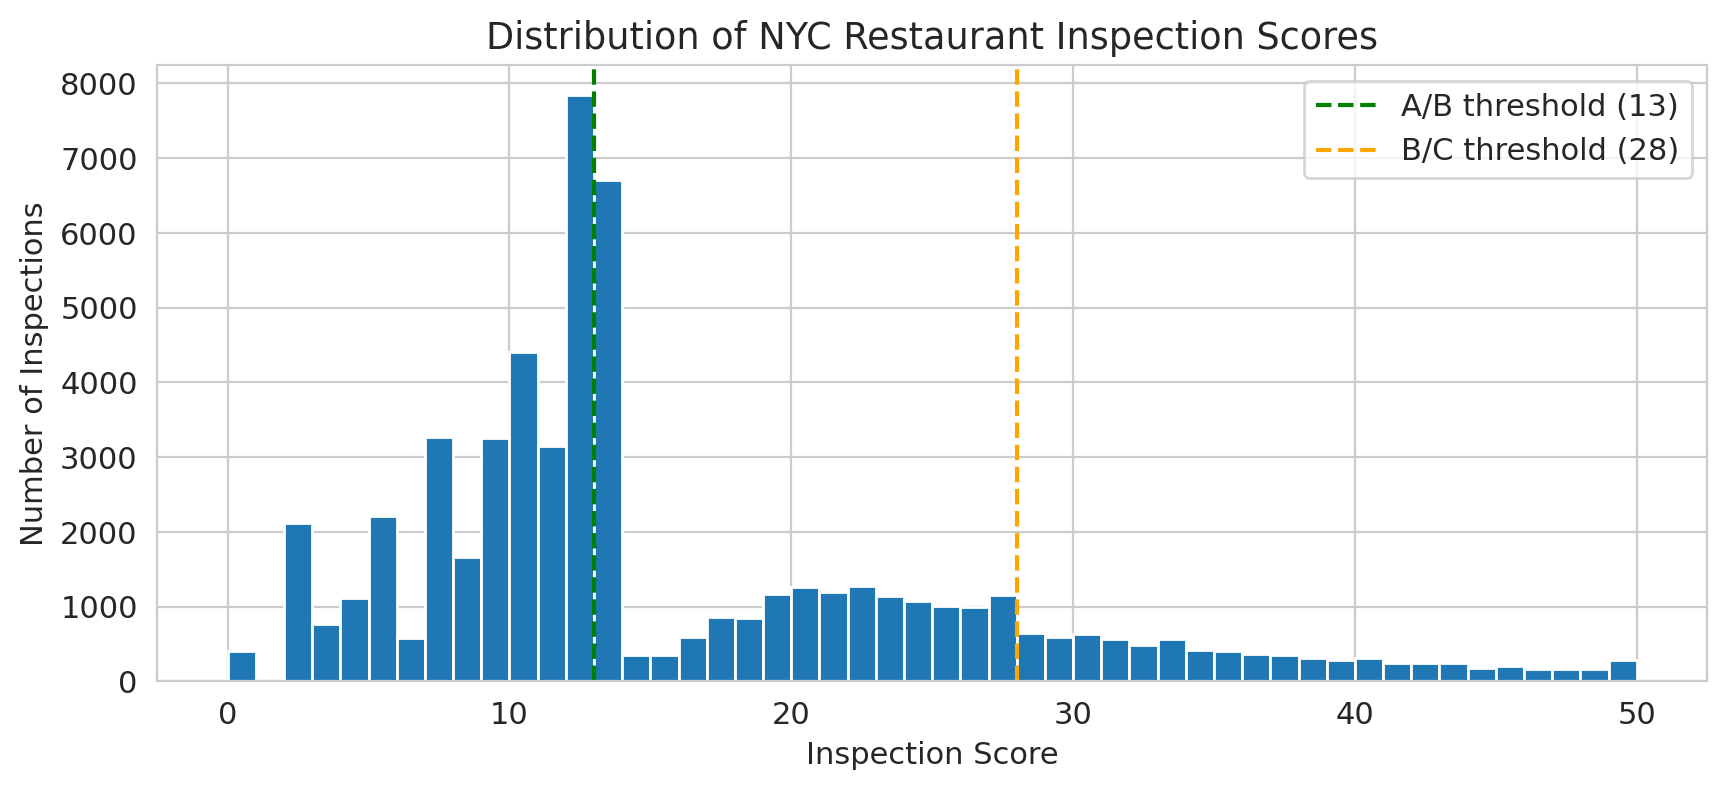

In [43]:
# Better histogram with more bins and limited range
inspections["SCORE"].hist(
    bins=50,           # More bars = more detail
    range=(0, 50),     # Focus on typical scores (0-50)
    edgecolor='white', # White borders between bars
)
plt.xlabel("Inspection Score")
plt.ylabel("Number of Inspections")
plt.title("Distribution of NYC Restaurant Inspection Scores")
plt.axvline(x=13, color='green', linestyle='--', label='A/B threshold (13)')
plt.axvline(x=28, color='orange', linestyle='--', label='B/C threshold (28)')
plt.legend()

**Observation**: Most restaurants score below 13 (Grade A range). The distribution is right-skewed with some high outliers.

### Kernel Density Estimation (KDE)

A KDE plot is a smoothed version of a histogram—it estimates the probability density function.

Text(0.5, 1.0, 'Density of Inspection Scores')

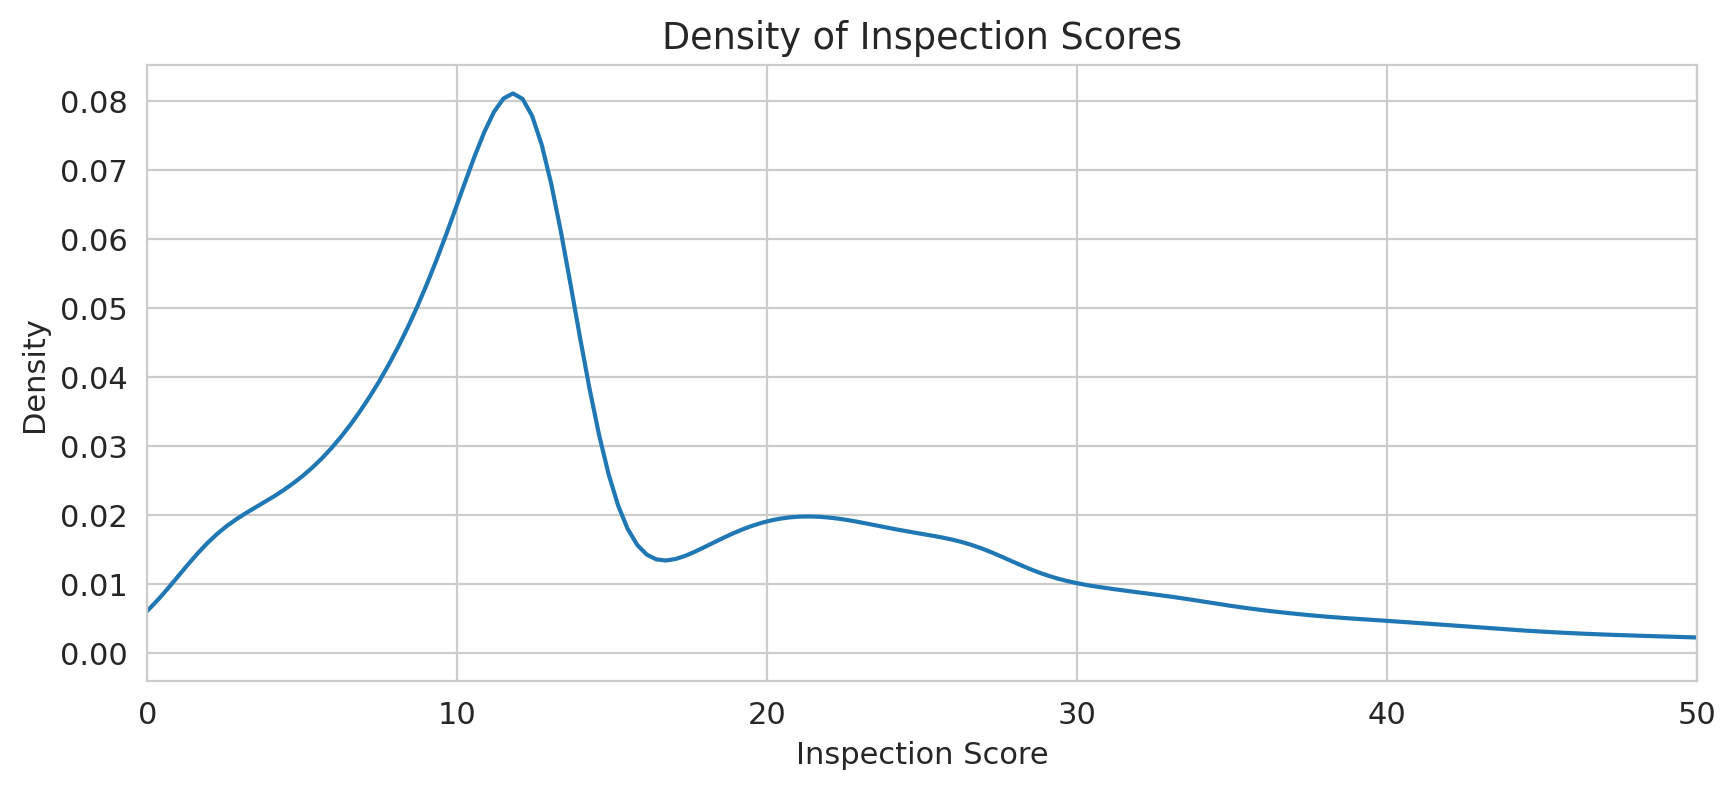

In [25]:
# KDE plot
inspections["SCORE"].plot(kind='kde', xlim=(0, 50))
plt.xlabel("Inspection Score")
plt.title("Density of Inspection Scores")

Text(0.5, 1.0, 'Distribution of Inspection Scores (Histogram + KDE)')

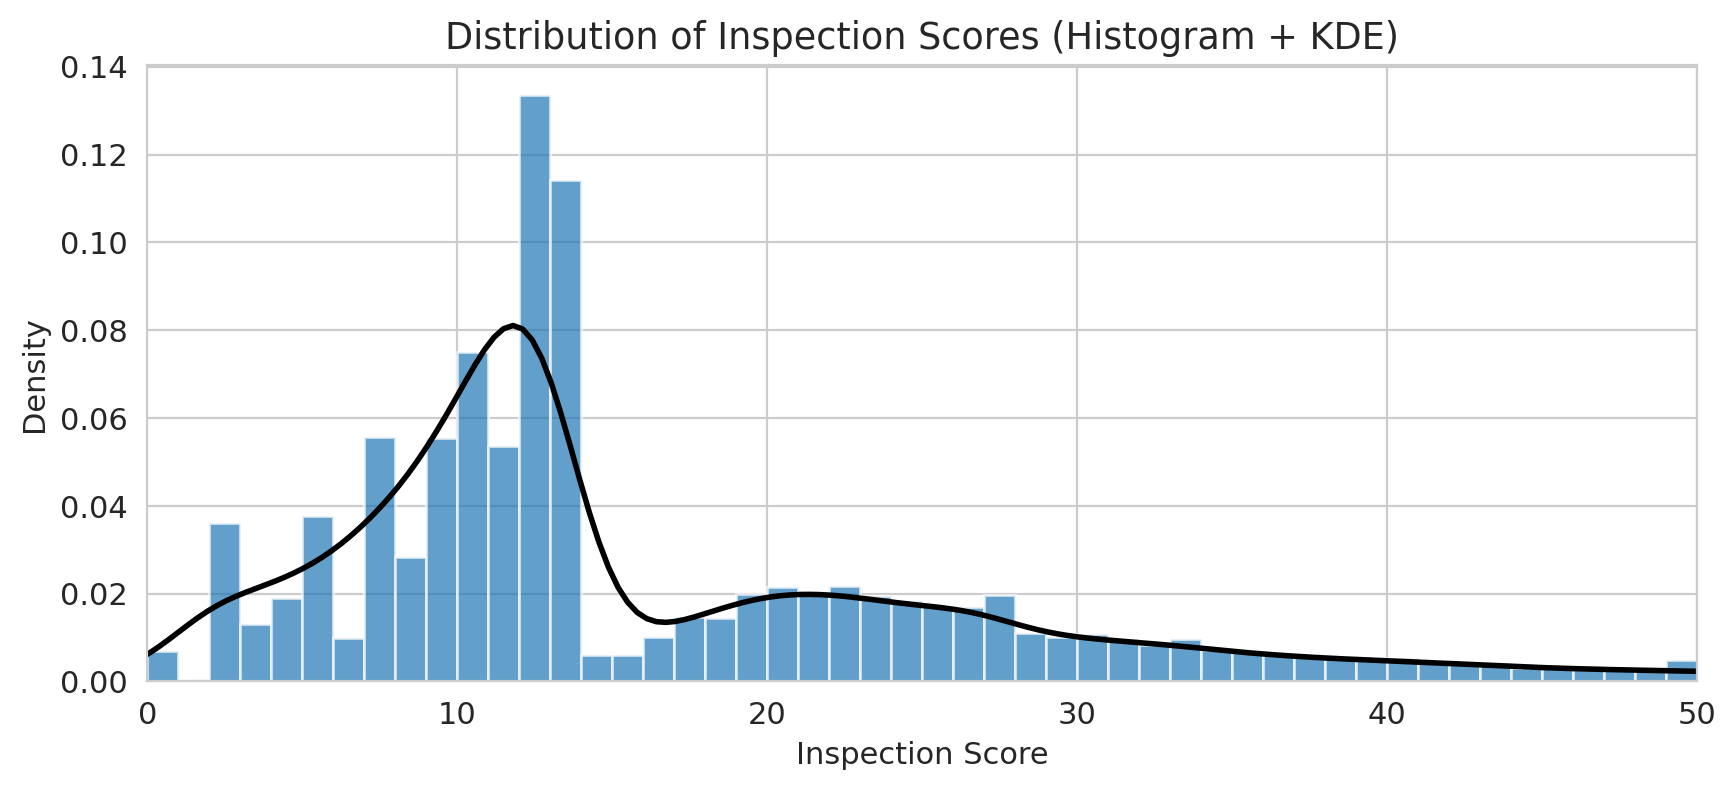

In [26]:
# Combine histogram and KDE
ax = inspections["SCORE"].hist(bins=50, range=(0, 50), density=True, alpha=0.7, edgecolor='white')
inspections["SCORE"].plot(kind='kde', xlim=(0, 50), ax=ax, color='black', linewidth=2)
plt.xlabel("Inspection Score")
plt.title("Distribution of Inspection Scores (Histogram + KDE)")

### Categorical Variables: value_counts()

For text/categorical columns, we want to know: What are the unique values and how often does each appear?

In [27]:
# Count restaurants by borough
restaurants["BORO"].value_counts()

,count
BORO,
Manhattan,8246
Brooklyn,5420
Queens,4726
Bronx,1935
Staten Island,784


In [28]:
# Count by cuisine type (top 15)
restaurants["CUISINE_DESCRIPTION"].value_counts().head(15)

,count
CUISINE_DESCRIPTION,
American,3971
Chinese,1725
Coffee/Tea,1671
Pizza,1316
Mexican,851
Italian,826
Latin American,792
Bakery Products/Desserts,751
Japanese,742


In [29]:
# How many unique cuisines are there?
print(f"Number of unique cuisine types: {restaurants['CUISINE_DESCRIPTION'].nunique()}")

Number of unique cuisine types: 89


### Visualizing Categorical Data: Bar Charts

Text(0.5, 1.0, 'Top 10 Cuisine Types in NYC')

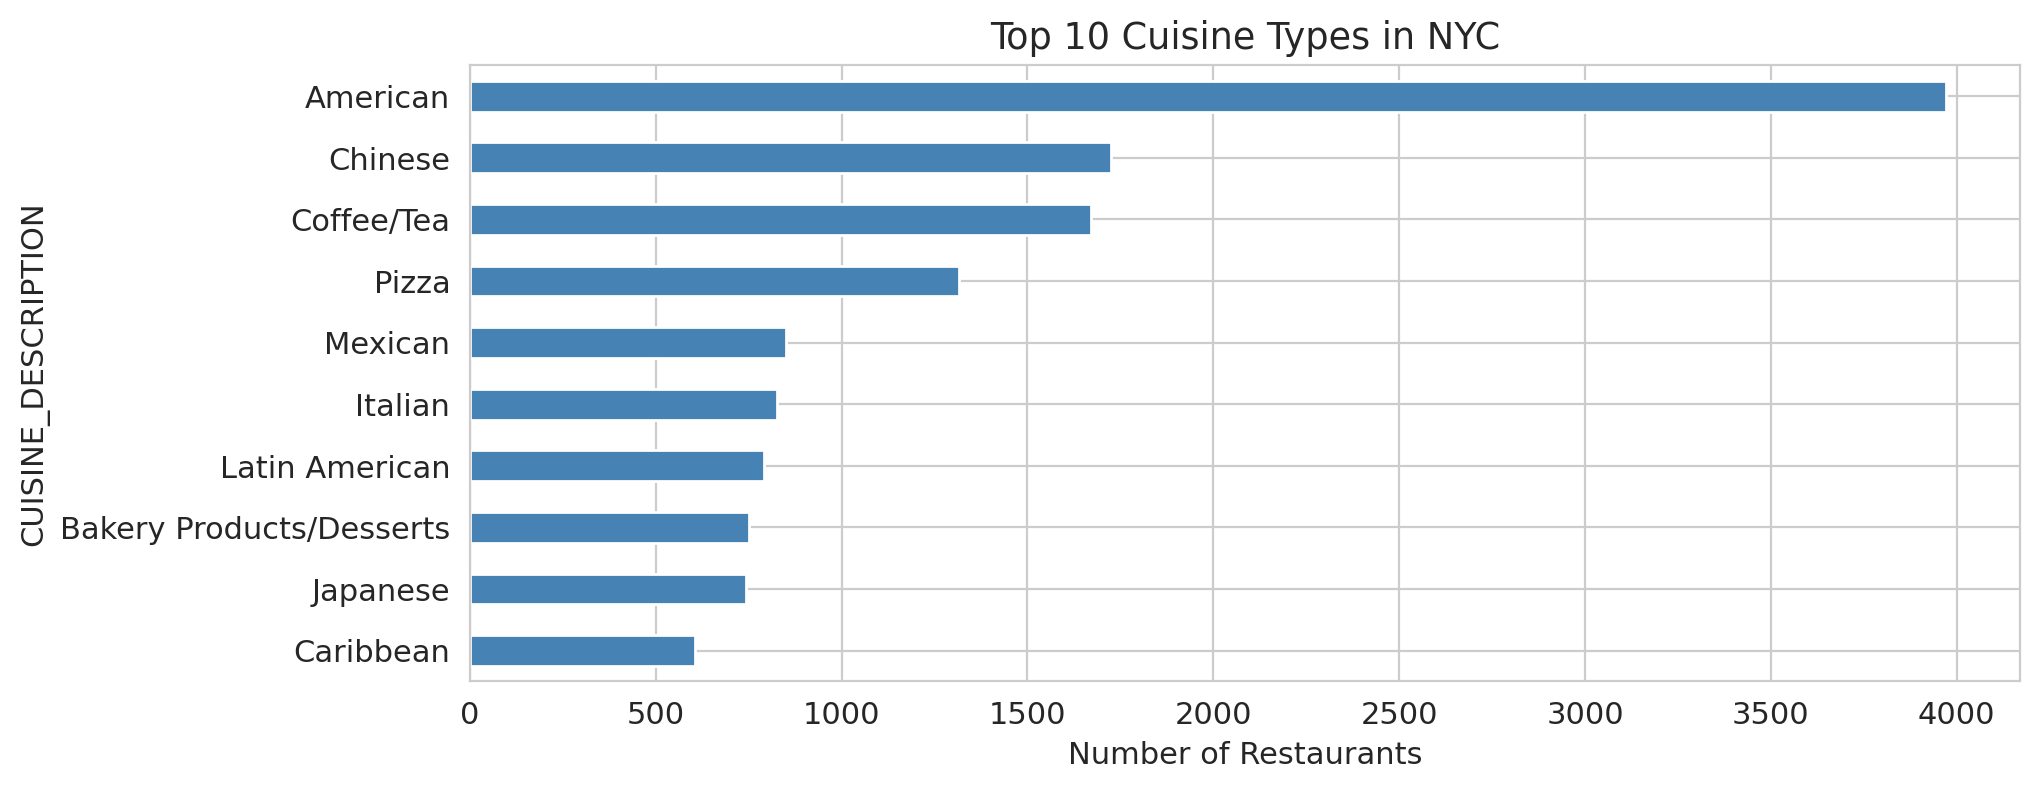

In [30]:
# Horizontal bar chart of top 10 cuisines
# (horizontal because labels are easier to read)
(
    restaurants["CUISINE_DESCRIPTION"]
    .value_counts()
    .head(10)
    .sort_values()  # Sort ascending so largest is at top
    .plot(kind='barh', color='steelblue')
)
plt.xlabel("Number of Restaurants")
plt.title("Top 10 Cuisine Types in NYC")

(array([0, 1, 2]), [Text(0, 0, 'A'), Text(1, 0, 'B'), Text(2, 0, 'C')])

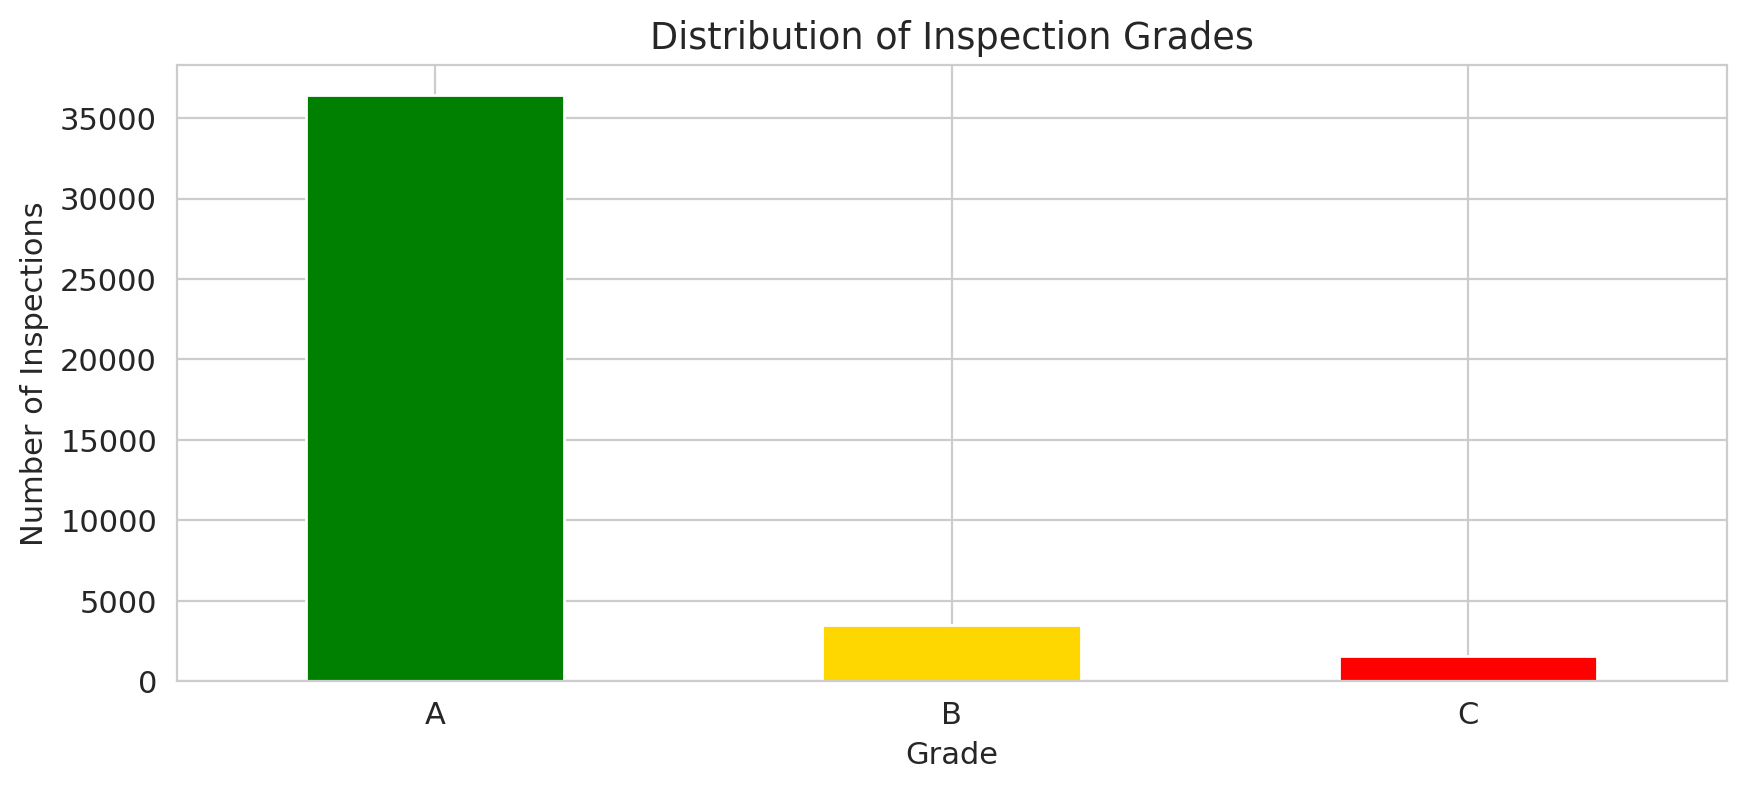

In [31]:
# Grade distribution
inspections["GRADE"].value_counts().sort_index().plot(kind='bar', color=['green', 'gold', 'red', 'gray', 'gray', 'gray'])
plt.xlabel("Grade")
plt.ylabel("Number of Inspections")
plt.title("Distribution of Inspection Grades")
plt.xticks(rotation=0)

### DateTime Variables

The `INSPECTION_DATE` column is a datetime type, which enables powerful time-based analysis.

In [32]:
# Date range of the data
print(f"Earliest inspection: {inspections['INSPECTION_DATE'].min()}")
print(f"Latest inspection:   {inspections['INSPECTION_DATE'].max()}")

Earliest inspection: 2016-01-21 00:00:00+00:00
Latest inspection:   2025-10-19 00:00:00+00:00


Text(0.5, 1.0, 'Inspections Over Time')

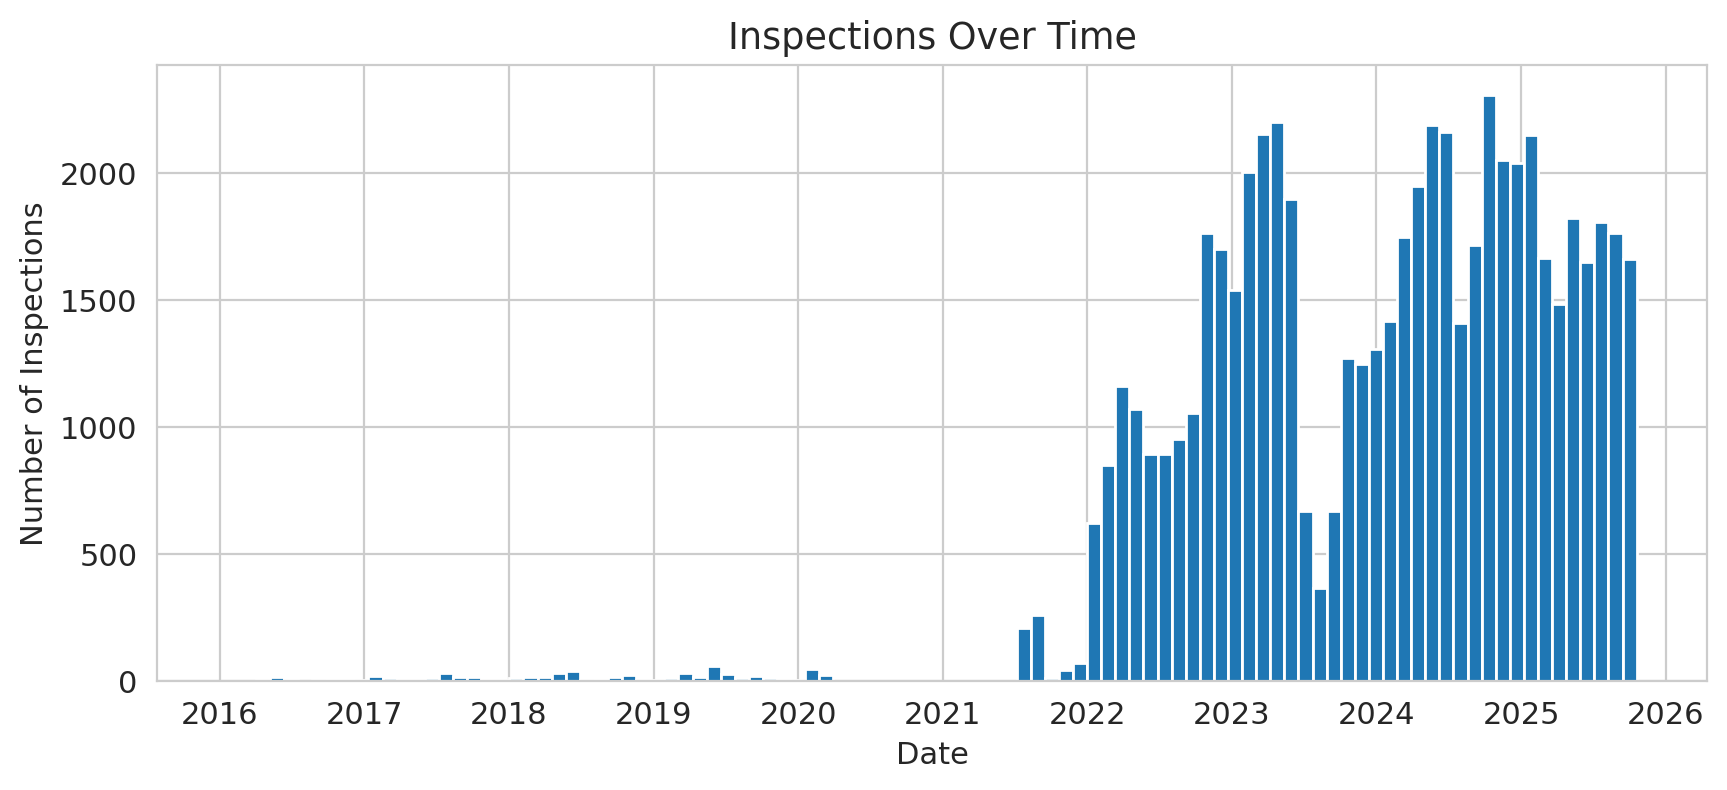

In [33]:
# Histogram of inspection dates
inspections["INSPECTION_DATE"].hist(bins=100, edgecolor='white')
plt.xlabel("Date")
plt.ylabel("Number of Inspections")
plt.title("Inspections Over Time")

### 🎯 Exercise 2: Explore Restaurant Chains

The `DBA` column contains restaurant names. Use `value_counts()` to answer:

1. What are the most common restaurant names (chains) in NYC?
2. How many DUNKIN' locations are there?
3. Create a horizontal bar chart of the top 10 restaurant chains

In [34]:
# Your code here


---

## Part 6: Geographic Exploration (Preview)

Since we have latitude and longitude data, let's create a quick geographic visualization. This is a preview of techniques we'll explore more deeply in the spatial data module.

<Axes: title={'center': 'Restaurant Locations in NYC'}, xlabel='LONGITUDE', ylabel='LATITUDE'>

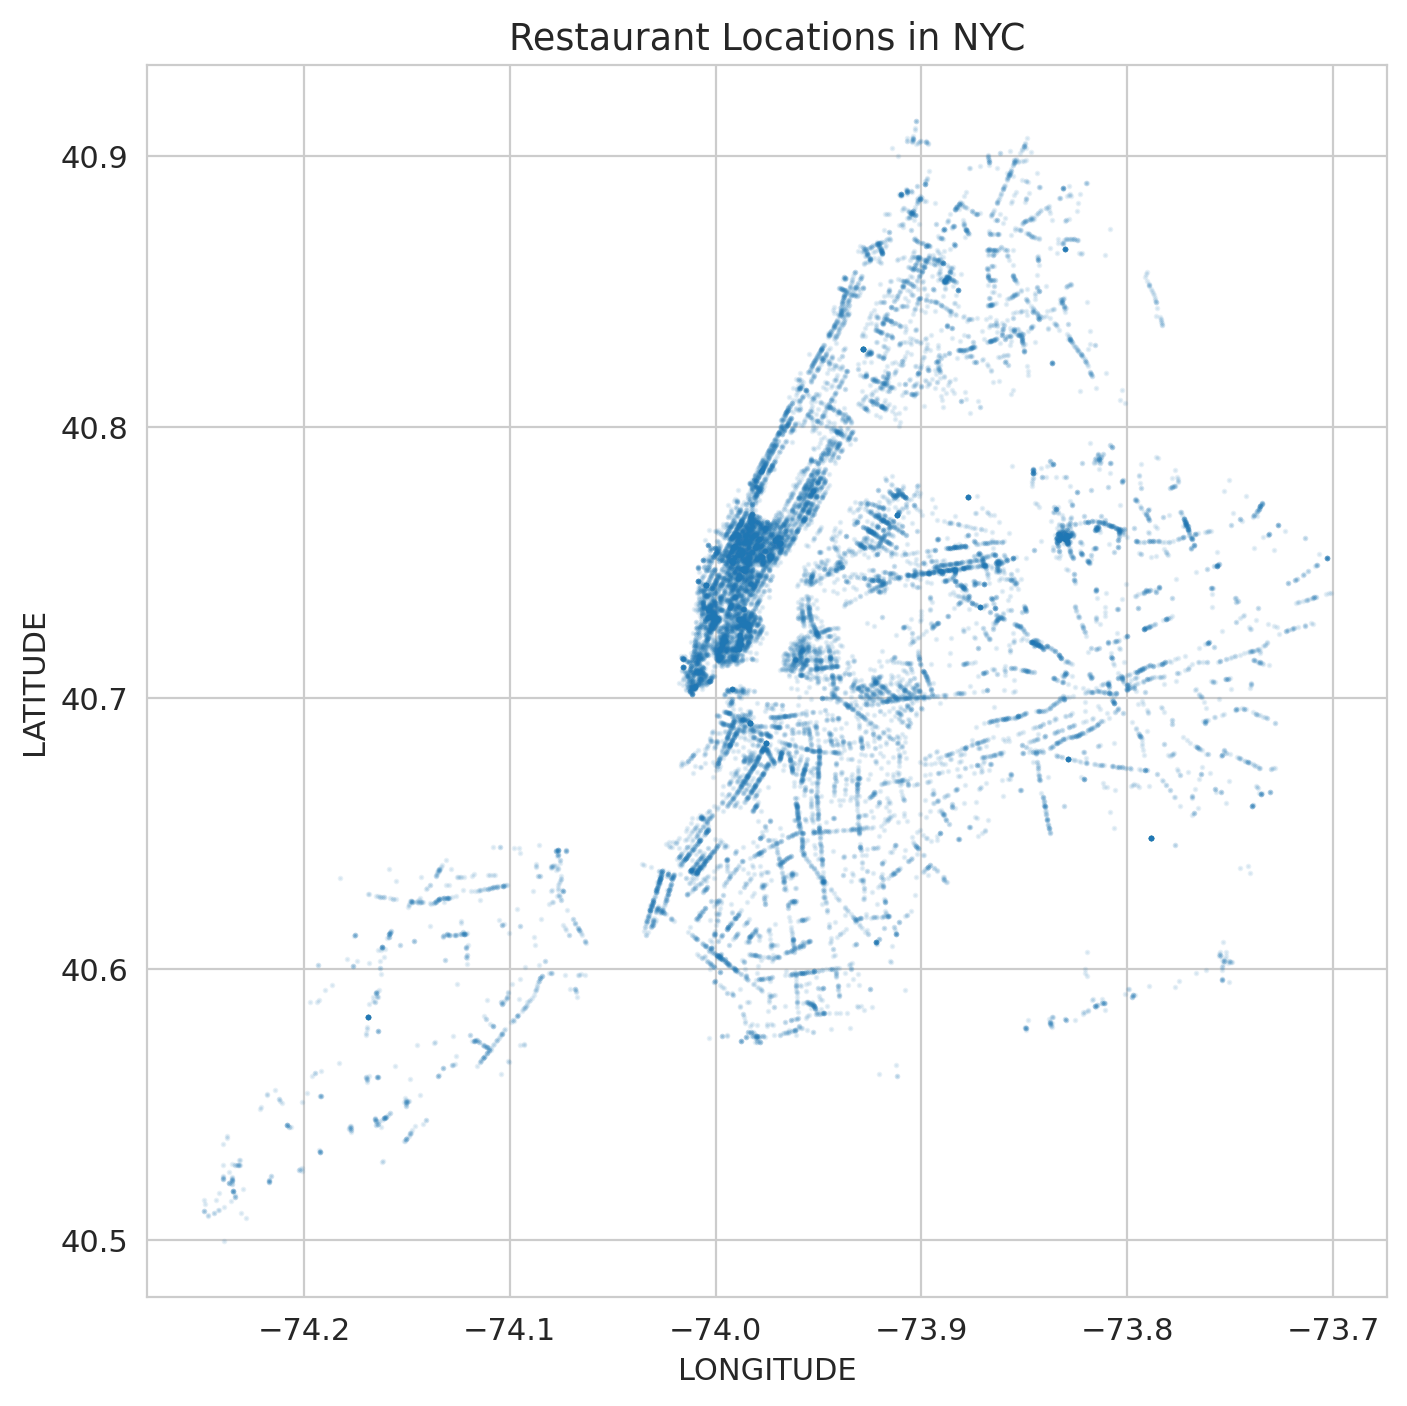

In [35]:
# Simple scatter plot of restaurant locations
restaurants.plot(
    kind='scatter',
    x='LONGITUDE',
    y='LATITUDE',
    alpha=0.1,      # Transparency (many overlapping points)
    s=1,            # Small dot size
    figsize=(8, 8),
    title="Restaurant Locations in NYC"
)

**Observation**: You can see the shape of NYC! The dense cluster at the center is Manhattan, with downtown having higher density. The large area to the right is Brooklyn and Queens.

### 🎯 Exercise 3: Create Manhattan-Only DataFrames

For later exercises, we'll want to compare Manhattan to other boroughs.

Write SQL queries to create:
1. `manh_restaurants` — restaurants in Manhattan only
2. `manh_inspections` — inspections for Manhattan restaurants only

**Hint**: Use `WHERE BORO = 'Manhattan'` in your SQL query.

In [36]:
# Your code here
sql = """
-- Write your query for Manhattan restaurants
"""

# manh_restaurants = client.query(sql).to_dataframe()
# print(f"Manhattan restaurants: {len(manh_restaurants):,}")

---

## Summary: What You Learned

### Core Concepts

| Concept | Description |
|---------|-------------|
| **DataFrame** | A 2D table (like a SQL result set) |
| **Series** | A single column from a DataFrame |
| **Index** | Row labels (usually 0, 1, 2, ...) |
| **dtypes** | Data types of each column |

### Key Methods

| Method | Purpose | Example |
|--------|---------|--------|
| `.head(n)` | View first n rows | `df.head(10)` |
| `.tail(n)` | View last n rows | `df.tail(5)` |
| `.sample(n)` | View n random rows | `df.sample(10)` |
| `.shape` | Get (rows, columns) | `df.shape` |
| `.columns` | Get column names | `df.columns` |
| `.dtypes` | Get data types | `df.dtypes` |
| `.info()` | Comprehensive overview | `df.info()` |
| `.describe()` | Numeric statistics | `df['col'].describe()` |
| `.value_counts()` | Count unique values | `df['col'].value_counts()` |
| `.nunique()` | Count distinct values | `df['col'].nunique()` |
| `.hist()` | Create histogram | `df['col'].hist(bins=50)` |
| `.plot()` | Create various plots | `df['col'].plot(kind='bar')` |

### What's Next?

In **Notebook A2**, you'll learn to manipulate data:
- Selecting rows (like SQL `WHERE`)
- Selecting columns (like SQL `SELECT`)
- Sorting, filtering, and joining tables
- Grouping and aggregating (like SQL `GROUP BY`)

---

## Exercise Solutions

In [37]:
# Exercise 1 Solutions
print("=== Exercise 1 ===")
# 1. Display inspections
# inspections

# 2. First 10 rows
# inspections.head(10)

# 3. Random rows
# inspections.sample(5)

# 4. Extract GRADE column
# inspections["GRADE"]

=== Exercise 1 ===


=== Exercise 2 ===
Top 10 restaurant chains:
DBA
DUNKIN                    328
STARBUCKS                 200
SUBWAY                    162
MCDONALD'S                158
POPEYES                   114
DUNKIN'                    85
CHIPOTLE MEXICAN GRILL     70
DOMINO'S                   68
BURGER KING                62
TACO BELL                  61
Name: count, dtype: int64

Number of DUNKIN' locations: 85


Text(0.5, 1.0, 'Top 10 Restaurant Chains in NYC')

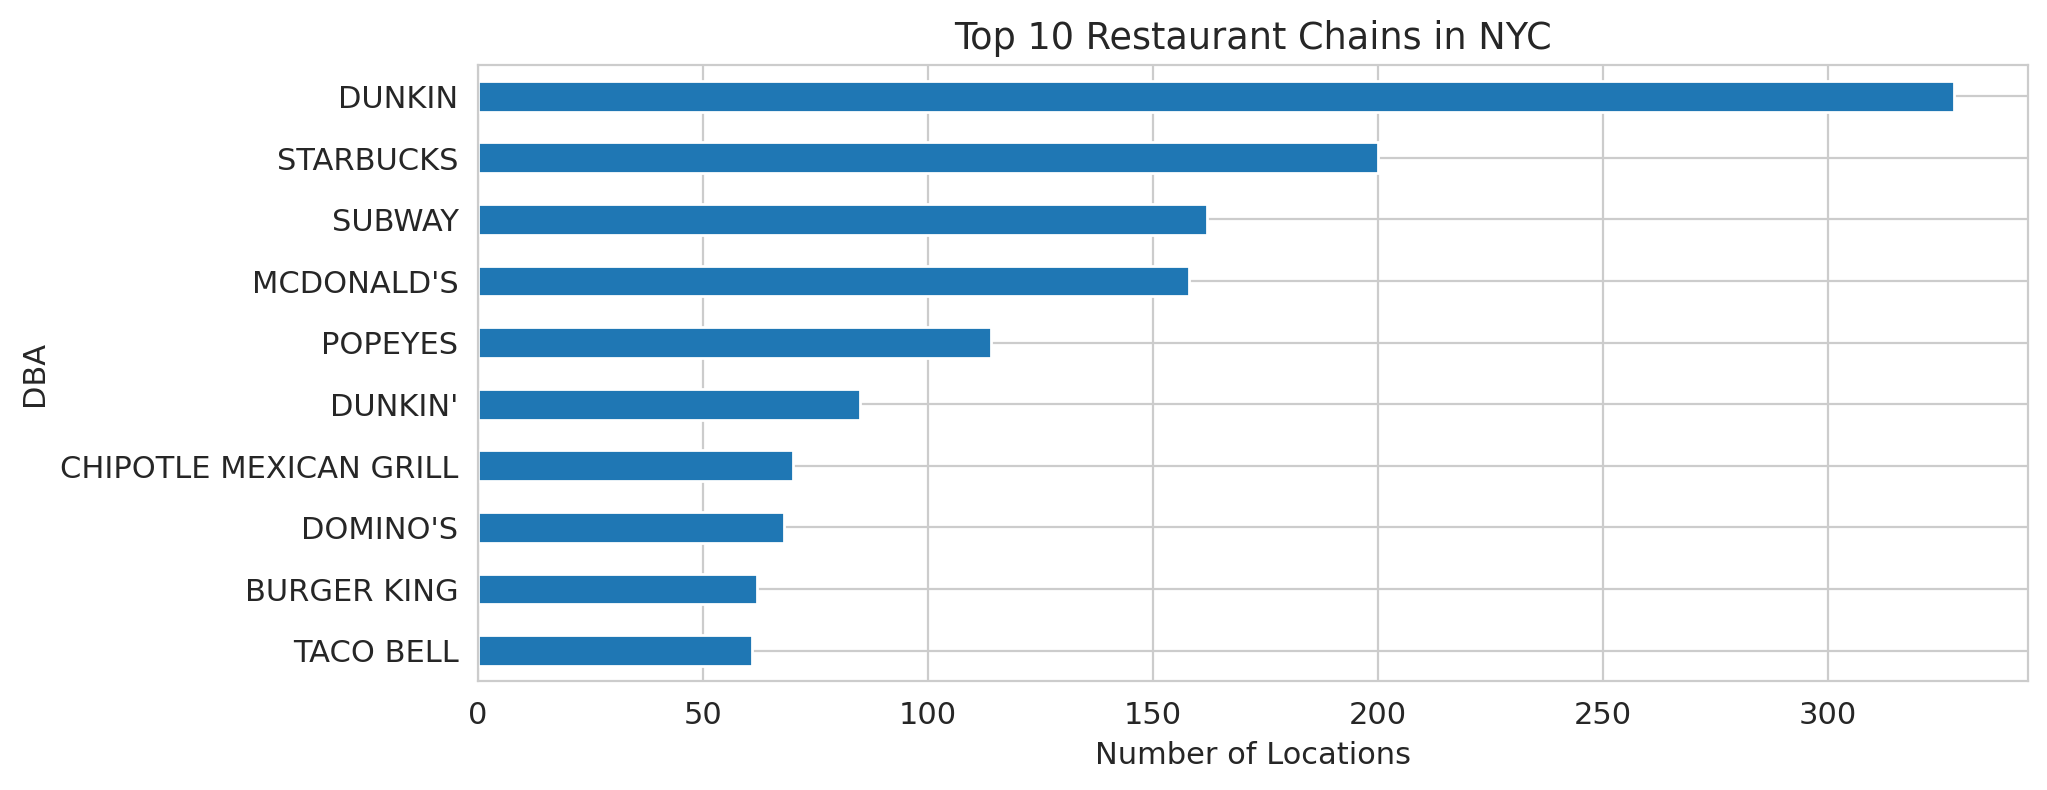

In [38]:
# Exercise 2 Solutions
print("=== Exercise 2 ===")

# 1. Most common restaurant names
print("Top 10 restaurant chains:")
print(restaurants["DBA"].value_counts().head(10))

# 2. DUNKIN' count
dunkin_count = restaurants[restaurants["DBA"] == "DUNKIN'"].shape[0]
print(f"\nNumber of DUNKIN' locations: {dunkin_count}")

# 3. Bar chart
restaurants["DBA"].value_counts().head(10).sort_values().plot(kind='barh')
plt.xlabel("Number of Locations")
plt.title("Top 10 Restaurant Chains in NYC")

In [39]:
# Exercise 3 Solution
print("=== Exercise 3 ===")

# Manhattan restaurants
sql = """
SELECT CAMIS, DBA, BUILDING, STREET, ZIPCODE, BORO,
       CUISINE_DESCRIPTION, LATITUDE, LONGITUDE
FROM `nyu-datasets.doh_restaurants.restaurants`
WHERE BORO = 'Manhattan'
"""
manh_restaurants = client.query(sql).to_dataframe()
print(f"Manhattan restaurants: {len(manh_restaurants):,}")

# Manhattan inspections
sql = """
SELECT R.CAMIS, R.DBA, R.ZIPCODE, R.BORO, R.CUISINE_DESCRIPTION,
       I.INSPECTION_DATE, I.INSPECTION_TYPE, I.SCORE, I.GRADE
FROM `nyu-datasets.doh_restaurants.restaurants` R
JOIN `nyu-datasets.doh_restaurants.inspections` I ON I.CAMIS = R.CAMIS
WHERE R.BORO = 'Manhattan'
"""
manh_inspections = client.query(sql).to_dataframe()
print(f"Manhattan inspections: {len(manh_inspections):,}")

=== Exercise 3 ===
Manhattan restaurants: 8,246
Manhattan inspections: 22,750
